# Programa de Capacitação de Processamento Digital de Sinais

![Texto Alternativo](images/V-CC_Color_Completa_TextoAzul.png)

### Desenvolvido por:
-   Elmer Pimentel Farias


# Filtros Adaptativos e Equalização de Canais

Filtros adaptativos são sistemas capazes de ajustar seus coeficientes automaticamente para minimizar um erro, adaptando-se a ambientes desconhecidos ou variantes no tempo. Diferente dos filtros fixos, eles operam em malha fechada, utilizando o erro entre a saída e um sinal desejado para atualizar seus pesos.



## Principais Algoritmos

* **LMS (Least Mean Squares):** O mais utilizado devido à sua simplicidade e baixo custo computacional. Baseia-se no gradiente estocástico para minimizar o erro quadrático médio.
    * **Equação de atualização:** $$\mathbf{w}(n+1) = \mathbf{w}(n) + \mu e(n) \mathbf{x}(n)$$
* **CMA (Constant Modulus Algorithm):** Essencial para **equalização cega** (sem sinal de referência), buscando restaurar o módulo constante de sinais modulados.
* **Outros (RLS, NLMS):** O **RLS** oferece convergência rápida com maior custo computacional, enquanto o **NLMS** normaliza o passo de adaptação para maior estabilidade.



## Livro-Texto Base

> **Adaptive Filtering: Algorithms and Practical Implementation (5ed)**
> *Paulo S. R. Diniz* 

Caps. 1, 2, 3 e 13

## Objetivos da Capacitação 

1.  **Implementação:** Codificar o algoritmo **LMS**.
2.  **Aplicação:** Realizar a **equalização de um canal passa-baixas**, visando mitigar a Interferência Intersimbólica (ISI).
3.  **Avaliação de Desempenho:**
    * Utilizar o **MSE (Mean Squared Error)** como métrica de convergência.
    * Analisar o impacto do **passo de adaptação ($\mu$)** (velocidade vs. erro residual).
    * Testar a robustez do sistema sob diferentes condições de **SNR**.



# O Algoritmo LMS (Least Mean Squares)

O diagrama de blocos acima ilustra a estrutura padrão de um filtro adaptativo. O algoritmo **LMS** atua dentro do bloco "Adaptive Algorithm", ajustando os coeficientes do filtro linear para minimizar o erro entre a saída do filtro e um sinal desejado.

![Texto Alternativo](images/lmsbasic.png)


Abaixo, descrevemos o funcionamento passo a passo com base nas variáveis ilustradas:

### 1. Definição das Variáveis

Com base no diagrama e na literatura do curso:

* $\mathbf{x}[k]$ : **Vetor de Entrada**. Contém a amostra atual e as amostras passadas do sinal de entrada (linha de atraso).
* $\mathbf{h}[k]$: **Vetor de Coeficientes**. Representa os pesos do filtro linear (FIR) no instante . O objetivo do LMS é encontrar os valores ótimos para este vetor.
* $\mathbf{y}[k]$: **Saída do Filtro**. É a estimativa do sinal desejado, calculada pela convolução (ou produto interno) entre a entrada e os coeficientes atuais.
* $\mathbf{d}[k]$: **Sinal Desejado** (ou Referência). É o sinal que o sistema tenta reproduzir ou identificar.
*$\mathbf{e}[k]$ : **Sinal de Erro**.  A diferença instantânea entre o que se deseja ($d[k]$) e o que o filtro entregou ($y[k]$).
### 2. O Ciclo de Funcionamento

O algoritmo opera em um ciclo contínuo de realimentação (feedback loop) composto por três etapas principais a cada iteração :

#### Passo 1: Filtragem (Cálculo da Saída)

O filtro linear processa o sinal de entrada $\mathbf{x}[k]$ com os coeficientes atuais $\mathbf{h}[k]$ para gerar a saída estimada:

$$y[k] = \mathbf{h}^T[k] \mathbf{x}[k]$$

#### Passo 2: Cálculo do Erro

O sistema compara a saída estimada $y[k]$ com o sinal desejado $d[k]$ através do somador (subtrator) mostrado no diagrama. Este erro guiará a adaptação:

$$e[k] = d[k] - y[k]$$


#### Passo 3: Atualização dos Pesos (Adaptive Algorithm)

Aqui entra o LMS. Ele utiliza o erro $e[k]$ para atualizar o vetor $\mathbf{h}[k]$, movendo-o na direção oposta ao gradiente do erro quadrático instantâneo. A equação de atualização é:

$$\mathbf{h}[k+1] = \mathbf{h}[k] + 2\mu e[k] \mathbf{x}[k]$$

Onde:

* :Onde:$\mathbf{h}[k+1]$: Novos coeficientes para a próxima iteração.
* $\mu$: Passo de adaptação (step-size). Controla a velocidade de convergência e a estabilidade do filtro.

### 3. Resumo do Algoritmo

O "segredo" do LMS é sua simplicidade computacional. Ao contrário do algoritmo de Wiener, que exige cálculos complexos de matrizes de correlação, o LMS usa o próprio erro instantâneo como uma estimativa estocástica do gradiente.

Para implementar em código, o laço de repetição segue esta lógica:

* 1- Recebe nova amostra $x[k]$ e $d[k]$.
* 2- Calcula $y[k]$.
* 3- Calcula $e[k]$.
* 4- Atualiza $\mathbf{h} \leftarrow \mathbf{h} + 2\mu e[k] \mathbf{x}[k]$.



### Bibliotecas Importadas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz
from numba import njit
from scipy.linalg import toeplitz, inv



# Objetivo: Equalização de Canal com Algoritmo LMS

Implementar e avaliar o desempenho do algoritmo **LMS (Least Mean Squares)** aplicado à equalização de um canal de comunicação.

![Texto Alternativo](images/equalilms.png)

### Estrutura do Sistema de Equalização

Baseado no diagrama acima, as variáveis do sistema são definidas como:
* $s[k]$ (Transmitted Signal): O sinal de informação original.
* Canal $H(z)$: Modela o meio de transmissão. Neste estudo, utilizamos um modelo passa-baixas
* $v[k]$ (Noise): Ruído aditivo (AWGN) somado ao sinal, simulando interferências térmicas ou do ambiente. O nível deste ruído define a SNR (Signal-to-Noise Ratio).
* $x[k]$ (Received Signal): O sinal distorcido e ruidoso que chega ao receptor. É a entrada do filtro adaptativo.


    $$x[k] = s[k] * h[k] + v[k]

* $$Delay $\Delta$: Um atraso proposital aplicado ao sinal desejado. Como o canal físico é causal, o equalizador precisa de um tempo de processamento para estimar o inverso do canal. Portanto, comparamos a saída do equalizador com uma versão atrasada do sinal original ($s[k-\Delta]$).$d[k]$.
* (Desired Signal): O sinal de referência para o treino do algoritmo, onde $d[k] = s[k-\Delta]$.
* $y[k]$ (Equalized Output): A tentativa do equalizador de reconstruir $d[k]$.


### Metodologia de Avaliação

O desempenho do equalizador será analisado através da curva de aprendizado e do erro em regime permanente, variando as seguintes condições:

1. **Passo de Adaptação ($\mu$):** Avaliaremos como diferentes valores de  influenciam a velocidade de convergência e a estabilidade do filtro. Espera-se um *trade-off*:  grande converge rápido mas com maior ruído residual (misadjustment);  pequeno é mais estável mas lento.
2. **Relação Sinal-Ruído (SNR):** Testaremos o sistema sob diferentes potências de ruído $v[k]$ . Isso determinará o "piso" de erro mínimo que o algoritmo consegue atingir (Erro de Wiener).

### Métrica de Desempenho: MSE

A principal métrica utilizada será o **Erro Quadrático Médio (MSE - Mean Squared Error)**. O algoritmo LMS busca minimizar a função custo instantânea $J[k] = |e[k]|^2$ .

A análise gráfica do MSE ao longo das iterações (curva de aprendizado) nos permitirá visualizar:



In [47]:
@njit
def lms(x, d, Ntaps, mu):
    """
    Implementação do LMS alinhada com o diagrama de blocos fornecido.
    
    Mapeamento Diagrama -> Código:
    - Received Signal x[k]    -> x
    - Desired Signal d[k]     -> d
    - Equalized Output y[k]   -> y
    - Adaptive Filter w[k]    -> w
    - Error Signal e[k]       -> e
    """
    N = len(x)
    
    # 1. Alocação de Memória
    # 'w' representa o vetor de pesos do filtro (Adaptive Filter w[k])
    w = np.zeros(Ntaps) 
    
    # Matriz para salvar o histórico de w[k] ao longo do tempo
    W = np.zeros((N - Ntaps, Ntaps))
    
    squared_e = np.zeros(N)
    y = np.zeros(N) # Equalized Output y[k]
    
    # 2. Inicialização do Buffer
    # Buffer representa o vetor x[k] dentro da linha de atraso do filtro
    buffer = x[0:Ntaps][::-1].copy()
    
    # 3. Loop Principal (Iteração k)
    # k representa o índice de tempo discreto, conforme diagrama
    for k in range(Ntaps, N):
        
        # Atualização do vetor de entrada (regressor)
        buffer[1:] = buffer[:-1]
        buffer[0] = x[k] # Entrada x[k] atual

        # A. Filtragem: y[k] = w[k]^T * x[k]
        # Gera a "Equalized Output"
        y[k] = np.dot(w, buffer)

        # B. Cálculo do Erro: e[k] = d[k] - y[k]
        # Nó de soma no canto inferior direito do diagrama
        e = d[k] - y[k]

        # C. Atualização dos Pesos (LMS Algorithm)
        # Seta "Weight Update" subindo para o filtro
        w += mu * e * buffer 

        # D. Armazenamento
        squared_e[k] = e**2
        
        # Salva o histórico dos pesos W
        W[k - Ntaps, :] = w

    return y, w, squared_e, W

 * Solução Ótima de Wiener, necessária para uso de comparação das aplicações do LMS como Equalizador de Canais

$$\mathbf{h}_{opt} = \mathbf{R}_{xx}^{-1} \mathbf{p}_{xd} \rightarrow \text{solução de Wiener que minimiza o MSE}$$

In [56]:
def solve_wiener(x_in, d_ref, N_filtro):
    # Autocorrelação de x (Rxx)
    r_xx = np.correlate(x_in, x_in, mode='full')
    center = len(r_xx) // 2
    r_xx_vec = r_xx[center : center + N_filtro] / len(x_in)
    R_xx = toeplitz(r_xx_vec)
    
    # Correlação cruzada entre d e x (pdx)
    p_dx = np.zeros(N_filtro)
    for k in range(N_filtro):
        # Precisamos alinhar x[n-k] com d[n]
        val = np.mean(d_ref[k:] * x_in[:len(x_in)-k])
        p_dx[k] = val
        
    # Resolve w = inv(R)*p
    return np.linalg.solve(R_xx, p_dx)

Piso de Ruído Teórico (MMSE): -22.06 dB


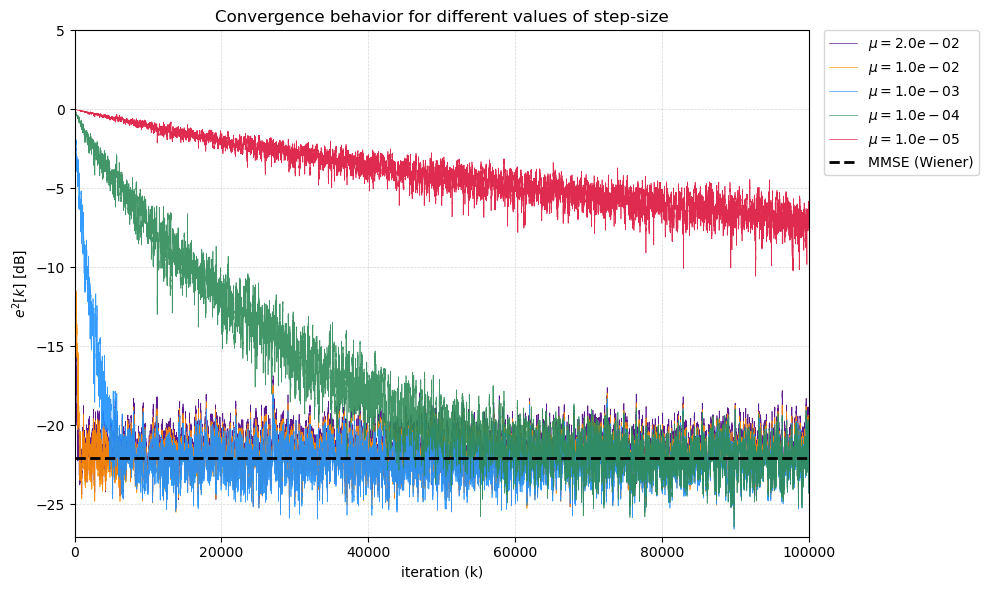

In [63]:


N_samples = 100000      # 100k para visual denso
Ntaps = 10              
delay = 4               
noise_power = 0.005     

# A. Geração de Sinais
np.random.seed(42)
d_original = np.sign(np.random.randn(N_samples))

# B. Canal Simples (O array explícito)
canal = np.array([1.0, 0.5, 0.2, 0.1]) 
x_clean = np.convolve(d_original, canal, mode='full')[:N_samples]

# C. Ruído
noise = np.random.normal(0, np.sqrt(noise_power), N_samples)
x = x_clean + noise

# D. Target (Desired) com atraso
d_train = np.zeros(N_samples)
d_train[delay:] = d_original[:-delay]

# ==============================================================================
# 3. CÁLCULO DA REFERÊNCIA (Wiener)
# ==============================================================================

w_opt = solve_wiener(x, d_train, Ntaps)

# Calcula o erro residual ótimo (Piso)
y_opt = np.convolve(x, w_opt, mode='full')[:N_samples]
e_opt = d_train - y_opt
mmse_linear = np.mean(e_opt[Ntaps:]**2)
mmse_db = 10 * np.log10(mmse_linear)

print(f"Piso de Ruído Teórico (MMSE): {mmse_db:.2f} dB")

# ==============================================================================
# 4. PLOTAGEM (VOLTANDO AO FORMATO DE LISTAS SIMPLES)
# ==============================================================================

# Definição simples das listas (como estava antes)
mu_values = [2e-2, 1e-2, 1e-3, 1e-4, 1e-5]
colors = ['indigo', 'darkorange', 'dodgerblue', 'seagreen', 'crimson']

window_len = 50 # Janela curta para manter a densidade visual

plt.figure(figsize=(10, 6))

# Loop usando enumerate para pegar mu e cor correspondente
for i, mu in enumerate(mu_values):
    
    # Executa sua função LMS
    _, _, squared_error, _ = lms(x, d_train, Ntaps, mu)
    
    # Processamento visual
    valid_error = squared_error[Ntaps:]
    mse_smooth = np.convolve(valid_error, np.ones(window_len)/window_len, mode='valid')
    error_db = 10 * np.log10(mse_smooth + 1e-20)
    
    plt.plot(error_db, color=colors[i], linewidth=0.5, alpha=0.9, label=f'$\mu = {mu:.1e}$')

# Linha do Wiener
plt.axhline(y=mmse_db, color='black', linestyle='--', linewidth=2, label='MMSE (Wiener)')

plt.title('Convergence behavior for different values of step-size')
plt.xlabel('iteration (k)')
plt.ylabel('$e^2[k]$ [dB]')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
plt.xlim(0, N_samples)
plt.ylim(mmse_db - 5, 5) 

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

* ## A solução de Wiener é o ponto ótimo onde a derivada da soma desses dois erros é zero. Ao alterar o SNR, você altera a curva de erro de ruído, deslocando esse ponto ótimo.

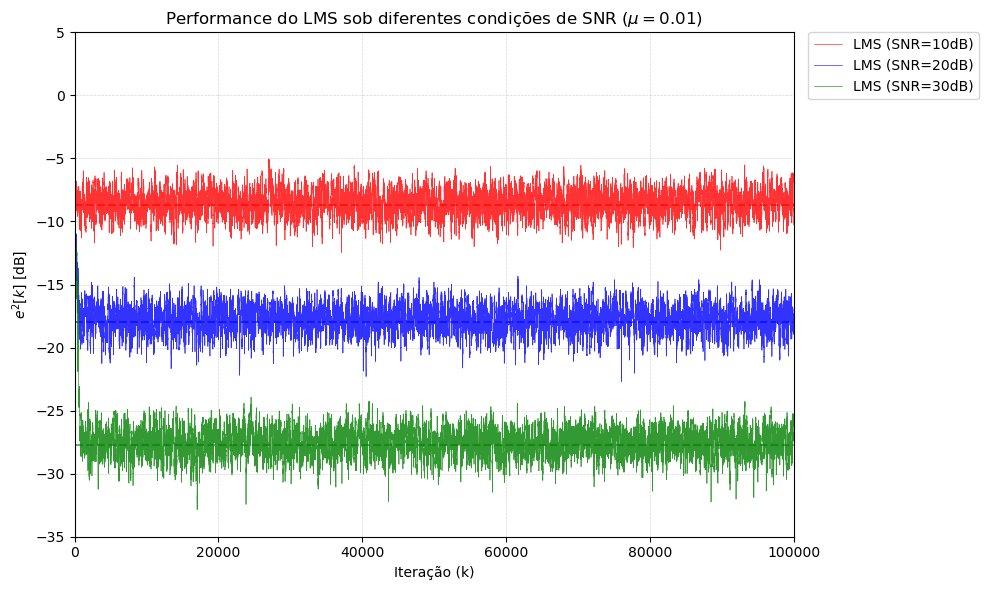

In [64]:
N_samples = 100000      
Ntaps = 10              
delay = 4               
mu_fixo = 0.01          # FIXAMOS O MU (um valor seguro que sabemos que converge)

# Geração de Sinais (Parte Fixa)
np.random.seed(42)
d_original = np.sign(np.random.randn(N_samples))
d_train = np.zeros(N_samples)
d_train[delay:] = d_original[:-delay]

# Canal Simples
canal = np.array([1.0, 0.5, 0.2, 0.1]) 
x_clean = np.convolve(d_original, canal, mode='full')[:N_samples]

# Calculamos a potência do sinal SEM ruído (necessário para calcular o SNR)
signal_power = np.var(x_clean)

# ==============================================================================
# 3. LOOP DE SNR E PLOTAGEM
# ==============================================================================

# Lista de SNRs para testar (dB)
snr_values = [10, 20, 30] 
colors = ['red', 'blue', 'green'] # Cores para cada SNR

window_len = 50 

plt.figure(figsize=(10, 6))

for i, snr_db in enumerate(snr_values):
    
    # --- A. CÁLCULO DO RUÍDO BASEADO NO SNR ---
    # SNR_dB = 10 * log10(P_sinal / P_ruido)
    # P_ruido = P_sinal / 10^(SNR/10)
    noise_variance = signal_power / (10**(snr_db / 10))
    
    # Gerar ruído específico para este loop
    noise = np.random.normal(0, np.sqrt(noise_variance), N_samples)
    x = x_clean + noise # Sinal com o SNR atual
    
    # --- B. EXECUÇÃO DO LMS ---
    _, _, squared_error, _ = lms(x, d_train, Ntaps, mu_fixo)
    
    # --- C. CÁLCULO DO WIENER (O Piso muda para cada SNR!) ---
    # Como o ruído mudou, o limite teórico mudou também.
    w_opt = solve_wiener(x, d_train, Ntaps)
    y_opt = np.convolve(x, w_opt, mode='full')[:N_samples]
    e_opt = d_train - y_opt
    mmse_db = 10 * np.log10(np.mean(e_opt[Ntaps:]**2))
    
    # --- D. PLOTAGEM ---
    # Curva de Aprendizado
    valid_error = squared_error[Ntaps:]
    mse_smooth = np.convolve(valid_error, np.ones(window_len)/window_len, mode='valid')
    error_db = 10 * np.log10(mse_smooth + 1e-20)
    
    color = colors[i]
    plt.plot(error_db, color=color, linewidth=0.5, alpha=0.8, label=f'LMS (SNR={snr_db}dB)')
    
    # Linha tracejada do ótimo teórico para este SNR
    plt.axhline(y=mmse_db, color=color, linestyle='--', linewidth=1.5, alpha=0.6)

plt.title(f'Performance do LMS sob diferentes condições de SNR ($\mu={mu_fixo}$)')
plt.xlabel('Iteração (k)')
plt.ylabel('$e^2[k]$ [dB]')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
plt.xlim(0, N_samples)
# Ajustar limites para ver bem as diferenças de piso
plt.ylim(-35, 5) 

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

SNR (dB)   | MSE Final LMS (dB)   | Wiener Teórico (dB)  | Diferença (dB) 
---------------------------------------------------------------------------
10         | -8.2703              | -8.7240              | 0.4537         
20         | -17.3710             | -17.8298             | 0.4589         
30         | -26.0637             | -26.4881             | 0.4245         


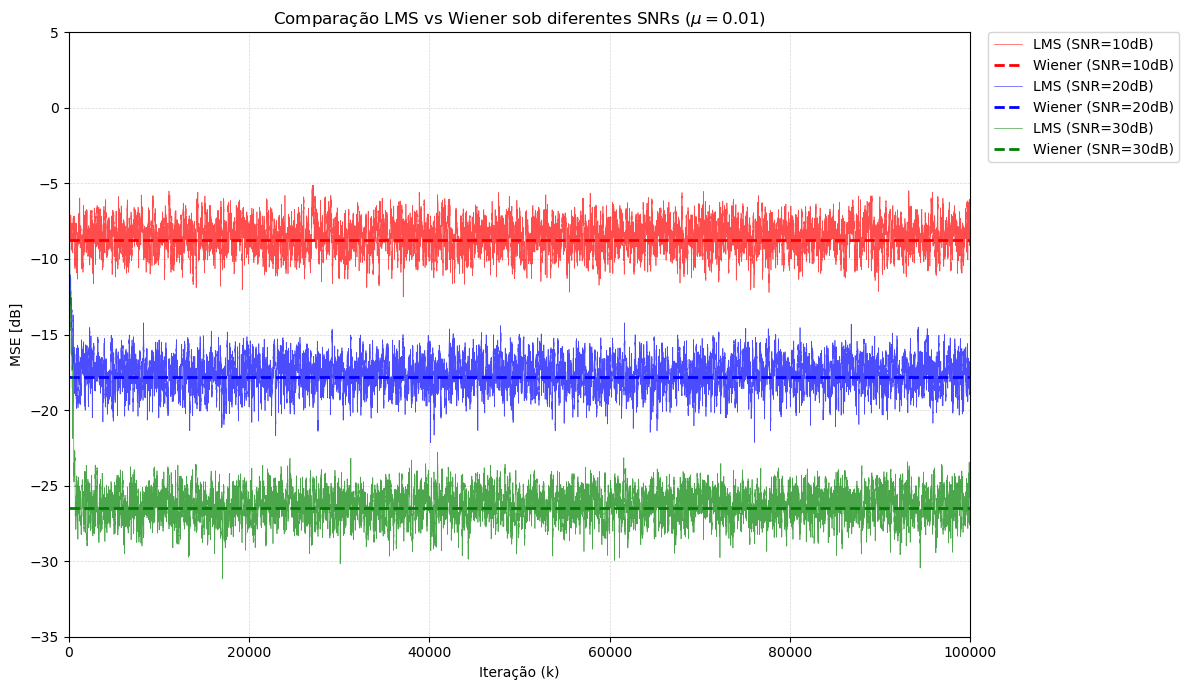

In [67]:
N_samples = 100000      
Ntaps = 10              
delay = Ntaps //2                
mu_fixo = 0.01          # Passo fixo

# Geração de Sinais
np.random.seed(42)
d_original = np.sign(np.random.randn(N_samples))
d_train = np.zeros(N_samples)
d_train[delay:] = d_original[:-delay]

# Canal
canal = np.array([1.0, 0.5, 0.2, 0.1]) 
x_clean = np.convolve(d_original, canal, mode='full')[:N_samples]
signal_power = np.var(x_clean)

# ==============================================================================
# 3. LOOP DE SNR E COMPARAÇÃO
# ==============================================================================

snr_values = [10, 20, 30] 
colors = ['red', 'blue', 'green'] 
window_len = 50 

plt.figure(figsize=(12, 7))

print(f"{'SNR (dB)':<10} | {'MSE Final LMS (dB)':<20} | {'Wiener Teórico (dB)':<20} | {'Diferença (dB)':<15}")
print("-" * 75)

for i, snr_db in enumerate(snr_values):
    
    # A. Configurar Ruído
    noise_variance = signal_power / (10**(snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_variance), N_samples)
    x = x_clean + noise
    
    # B. Rodar LMS
    _, _, squared_error, _ = lms(x, d_train, Ntaps, mu_fixo)
    
    # C. Rodar Wiener (Para saber o limite deste cenário específico)
    w_opt = solve_wiener(x, d_train, Ntaps)
    # Calcular o erro residual do Wiener
    y_opt = np.convolve(x, w_opt, mode='full')[:N_samples]
    e_opt = d_train - y_opt
    mmse_linear = np.mean(e_opt[Ntaps:]**2)
    mmse_db = 10 * np.log10(mmse_linear)
    
    # D. Calcular erro final do LMS (média das últimas 10k amostras)
    lms_final_mse = np.mean(squared_error[-10000:])
    lms_final_db = 10 * np.log10(lms_final_mse)
    
    print(f"{snr_db:<10} | {lms_final_db:<20.4f} | {mmse_db:<20.4f} | {abs(lms_final_db - mmse_db):<15.4f}")

    # E. Plotagem
    color = colors[i]
    
    # Curva LMS
    valid_error = squared_error[Ntaps:]
    mse_smooth = np.convolve(valid_error, np.ones(window_len)/window_len, mode='valid')
    error_db = 10 * np.log10(mse_smooth + 1e-20)
    
    # Plotamos com label explícito
    plt.plot(error_db, color=color, linewidth=0.5, alpha=0.7, label=f'LMS (SNR={snr_db}dB)')
    
    # Linha Wiener (Tracejada e mais escura)
    # Adicionei o label aqui para aparecer na legenda
    plt.axhline(y=mmse_db, color=color, linestyle='--', linewidth=2, label=f'Wiener (SNR={snr_db}dB)')

plt.title(f'Comparação LMS vs Wiener sob diferentes SNRs ($\mu={mu_fixo}$)')
plt.xlabel('Iteração (k)')
plt.ylabel('MSE [dB]')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
plt.xlim(0, N_samples)
plt.ylim(-35, 5) 

# Legenda posicionada fora
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

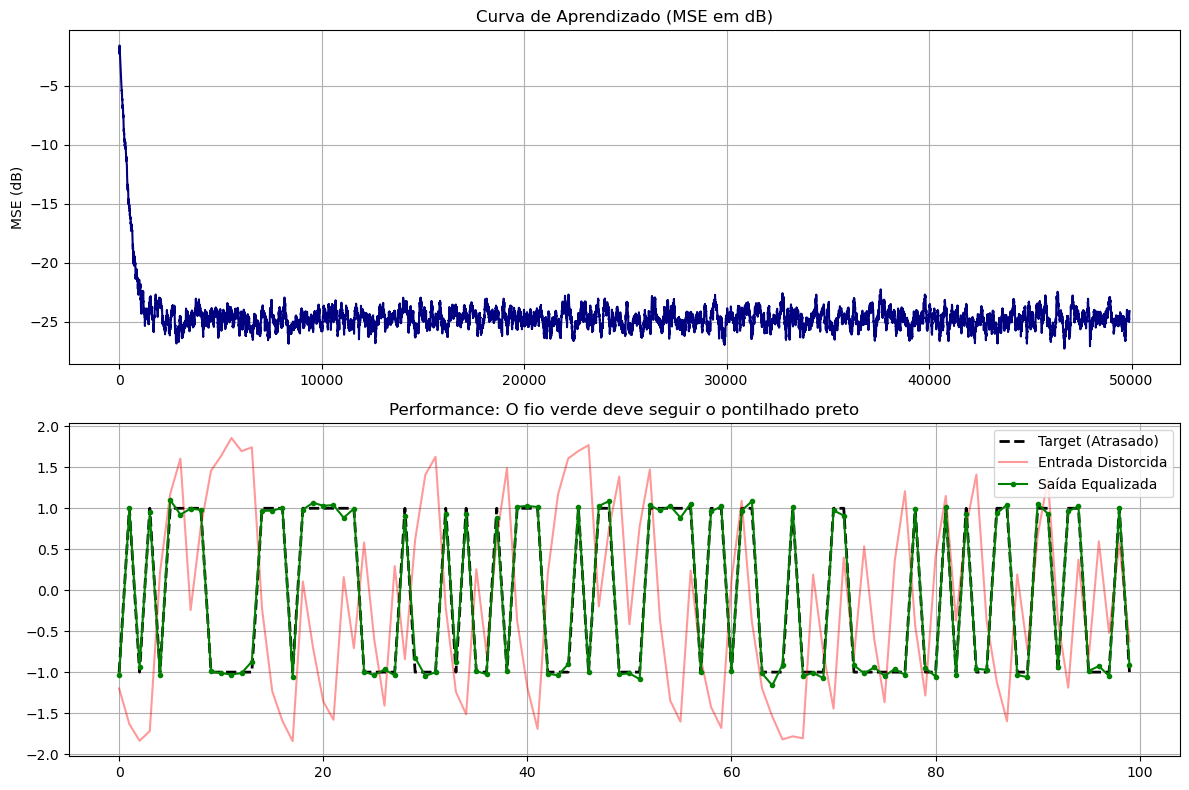

Canal Original: [1.  0.5 0.2 0.1]
Pesos do Equalizador (Primeiros 5): [ 0.001 -0.     0.     0.003 -0.004]


In [31]:
# --- SIMULAÇÃO ---

# Parâmetros
from scipy import signal


N_samples = 50000
Ntaps = 20      
mu = 0.005      
atraso = Ntaps // 2  # Delay para permitir causalidade 
 # Atraso para centralizar o equalizador

# A. Sinal
d_original = np.sign(np.random.randn(N_samples))

# B. Canal (Usando lfilter para simular sistema causal t=0)
canal = np.array([1.0, 0.5, 0.2, 0.1]) 
x_sem_ruido = signal.lfilter(canal, 1, d_original)

# C. Ruído
x = x_sem_ruido + np.random.normal(0, 0.05, N_samples)

# D. CORREÇÃO 3: Sincronização (Delay)
# O equalizador tentará recuperar d[k - atraso]
d_treino = np.zeros(N_samples)
# O sinal desejado é o original atrasado
d_treino[atraso:] = d_original[:-atraso]

# --- Execução ---
out, h_final, erro_quad, historico_h = lms(x, d_treino, Ntaps, mu)

# --- Visualização ---
plt.figure(figsize=(12, 8))

# Gráfico 1: MSE
plt.subplot(2, 1, 1)
# Plotando em dB para ver melhor a queda
mse_db = 10 * np.log10(np.convolve(erro_quad, np.ones(100)/100, mode='valid') + 1e-12)
plt.plot(mse_db, color='navy')
plt.title('Curva de Aprendizado (MSE em dB)')
plt.ylabel('MSE (dB)')
plt.grid(True)

# Gráfico 2: Comparação Visual
# Vamos dar zoom no meio, onde já convergiu
zoom_start = 49000
zoom_end = 49100

plt.subplot(2, 1, 2)
# Sinal Desejado (O que queremos)
plt.plot(d_treino[zoom_start:zoom_end], 'k--', linewidth=2, label='Target (Atrasado)')
# Sinal Distorcido (O que chegou)
plt.plot(x[zoom_start:zoom_end], 'r-', alpha=0.4, label='Entrada Distorcida')
# Saída do Equalizador
plt.plot(out[zoom_start:zoom_end], 'g.-', linewidth=1.5, label='Saída Equalizada')

plt.title('Performance: O fio verde deve seguir o pontilhado preto')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Verificação dos coeficientes
print("Canal Original:", canal)
print("Pesos do Equalizador (Primeiros 5):", np.round(h_final[:5], 3))


In [ ]:
# Parâmetros
N_samples = 50000
Ntaps = 20      
mu = 0.001      
atraso = 10     

# Geração do sinal
d_original = np.sign(np.random.randn(N_samples))
canal = np.array([1.0, 0.5, 0.2, 0.1]) 
x_sem_ruido = signal.lfilter(canal, 1, d_original)
x = x_sem_ruido + np.random.normal(0, 0.05, N_samples)

# Cria o sinal desejado com atraso (Sincronismo)
d_treino = np.zeros(N_samples)
d_treino[atraso:] = d_original[:-atraso]


y_lms, h_lms, erro, historico = lms(x, d_treino, Ntaps, mu)

w_wiener = solve_wiener(x, d_treino, Ntaps)

#TABELA COMPARATIVA (PRINT DA MATRIZ)


print(f"{'TAP':^5} | {'LMS (Seu Código)':^18} | {'WIENER (Teórico)':^18} | {'DIFERENÇA':^12}")
print("-" * 60)

erro_total = 0
for k in range(Ntaps):
    val_lms = h_lms[k]
    val_wiener = w_wiener[k]
    diff = abs(val_lms - val_wiener)
    erro_total += diff
    
    # Formatação bonita dos números
    print(f"{k:02d}    | {val_lms: .6f}           | {val_wiener: .6f}           | {diff:.6f}")

print("-" * 60)
print(f"Erro Médio Absoluto (MAE): {erro_total/Ntaps:.8f}")

# Validação Rápida
if erro_total/Ntaps < 0.05:
    print("\n LMS convergiu para a solução ótima!")
else:
    print("\n LMS ainda está longe do ótimo. Tente ajustar mu.")

 TAP  |  LMS (Seu Código)  |  WIENER (Teórico)  |  DIFERENÇA  
------------------------------------------------------------
00    |  0.000040           | -0.000322           | 0.000363
01    |  0.000364           |  0.000410           | 0.000046
02    | -0.002857           | -0.000588           | 0.002269
03    |  0.000689           | -0.000037           | 0.000726
04    | -0.000438           |  0.000318           | 0.000756
05    | -0.001395           | -0.000425           | 0.000969
06    |  0.003637           |  0.000487           | 0.003150
07    | -0.003750           | -0.000373           | 0.003377
08    |  0.001727           |  0.000008           | 0.001719
09    |  0.000458           |  0.001269           | 0.000811
10    |  0.997884           |  0.996523           | 0.001360
11    | -0.498475           | -0.497342           | 0.001133
12    |  0.048498           |  0.049150           | 0.000652
13    | -0.025541           | -0.024706           | 0.000835
14    |  0.052424     

## Tabela de Trade-offs: Parâmetros do LMS

A escolha dos parâmetros do algoritmo LMS envolve um compromisso constante entre velocidade de convergência, precisão final (erro residual) e estabilidade.

| Parâmetro | Símbolo | Valor Alto (High) | Valor Baixo (Low) | Impacto Principal |
| :--- | :---: | :--- | :--- | :--- |
| **Passo de Adaptação** | $\mu$ (mu) | **Vantagem:** Convergência rápida (aprende depressa).<br>**Risco:** Erro residual alto (misadjustment), oscilação e possível instabilidade/divergência. | **Vantagem:** Alta precisão no estado estacionário (erro residual mínimo) e estabilidade robusta.<br>**Risco:** Convergência lenta (pode não acompanhar variações rápidas do sistema). | Controla o equilíbrio entre **Velocidade vs. Precisão**. |
| **Ordem do Filtro** | $N_{taps}$ | **Vantagem:** Melhor resolução espectral; capaz de modelar sistemas com respostas ao impulso longas (ecos distantes).<br>**Risco:** Maior custo computacional; convergência mais lenta; maior "ruído de gradiente". | **Vantagem:** Rápido processamento; menor variância na estimativa.<br>**Risco:** *Underfitting* (não consegue modelar a complexidade do sistema); performance pobre se o canal tiver memória longa. | Define a **Capacidade de Modelagem vs. Custo Computacional**. |
| **Número de Amostras** | $N$ | **Vantagem:** Garante que o filtro atinja o regime permanente (steady-state), mesmo com $\mu$ pequeno.<br>**Risco:** Maior tempo de processamento/simulação; latência na resposta. | **Vantagem:** Simulação rápida.<br>**Risco:** O filtro pode ser interrompido ainda na fase transiente (aprendizado incompleto). | Define a **Suficiência Estatística** para a convergência. |

1. O Passo de Adaptação ($\mu$)

O $\mu$ regula o tamanho do salto que damos na superfície de erro em direção ao mínimo global.
* Teoria: O LMS é uma aproximação estocástica do Steepest Descent. O erro em regime permanente (Steady-State Mean Square Error - MSE) é dado por:

    $$J(\infty) = J_{min} + \text{Excesso de MSE}$$

Onde o "Excesso de MSE" é proporcional a $\mu$.

* Conclusão: Um $\mu$ grande faz você descer a "montanha do erro" correndo (rápido), mas você nunca para quieto no fundo do vale (fica oscilando ao redor do ponto ótimo), gerando um ruído de fundo constante chamado Misadjustment. Um $\mu$ pequeno desce devagar, mas para exatamente no fundo.

2. O Número de Taps ($N_{taps}$)
Define a memória temporal do filtro. Se o sistema desconhecido (ex: um canal acústico ou um cabo) tem uma resposta ao impulso que dura $T$ segundos, e sua taxa de amostragem é $F_s$, o filtro precisa de no mínimo $N_{taps} \approx T \times F_s$ para "cobrir" esse efeito.

* Teoria (Complexidade): O LMS tem complexidade $O(N_{taps})$ por iteração. Dobrar os taps dobra o tempo de execução.

* Teoria (Ruído): Quanto mais coeficientes você tem para estimar, mais "ruído" entra no cálculo do gradiente estimado, especialmente se o sinal de entrada não for rico em frequências (excitação persistente). Usar taps demais desnecessariamente piora a performance.


3. Quantidade de Amostras ($N$ ou Samples)

Este parâmetro é uma consequência da escolha do $\mu$. O LMS tem uma constante de tempo de aprendizado ($\tau_{mse}$), que é inversamente proporcional a $\mu$.

* Relação:$$\tau_{mse} \approx \frac{1}{4 \mu \lambda_{avg}}$$
(Onde $\lambda_{avg}$ é a média dos autovalores da correlação do sinal).

* Na prática: Se você diminui o $\mu$ pela metade para ganhar precisão, você precisará (grosso modo) do dobro de amostras ($N$) para que o filtro chegue no mesmo ponto de aprendizado.